# Create a Forecast plot given a stored model

### Notebook Configuration

In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)

### Imports

In [2]:
import matplotlib.pyplot as plt

plt.style.use("bmh")
plt.rcParams["axes.axisbelow"] = True
import numpy as np
import pandas
import pandas as pd
from pandas import DataFrame, Index, Series, Timedelta, Timestamp
import matplotlib.dates as mdates
rng = np.random.default_rng()
np.set_printoptions()

import torch
import torchinfo
from torch import Tensor, jit, tensor
from torch.utils.data import DataLoader
from copy import deepcopy

INFO:numexpr.utils:Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


### Enter Path and Name

In [3]:
ID = (510, 16866)  # the Run_id / Experiment_id we want to plot.
# files:  2021-11-12T00:52:10 2021-11-12T00:51:55 2021-11-12T00:51:48
# "checkpoints/2021-11-15T12:05:00/LinODEnet-0"
# "checkpoints/LinODEnet/KIWI_RUNS/skew_allways/2021-11-15T16:05:41/LinODEnet-0"
# "adam/2021-11-15T20:38:52/LinODEnet-0"
PATH = "checkpoints/LinODEnet/KIWI_RUNS/"
NAME = "SurrLoss+Sequential_Filter/2021-12-20T13:43:00/LinODEnet-70"
# the model checkpoint, should be a zip-archive created by torch.save / torch.jit.save
MODEL_FILE = PATH + NAME
DEVICE = torch.device("cpu")
DTYPE = torch.float32
NAN = tensor(float("nan"), dtype=DTYPE, device=DEVICE)
PRD_HORIZON = 120
OBS_HORIZON = 240
HORIZON = SEQLEN = OBS_HORIZON + PRD_HORIZON

## Intialize the task

In [4]:
from tsdm.tasks import KIWI_RUNS_TASK

task = KIWI_RUNS_TASK(
    forecasting_horizon=PRD_HORIZON,
    observation_horizon=OBS_HORIZON,
)

INFO:tsdm.config._config:Available Models: {'Latent-ODE', 'BRITS', 'NCDE', 'IP-Net', 'SET-TS', 'NODE', 'mTAN', 'Informer', 'ODE-RNN', 'N-BEATS', 'TPA', 'M-RNN', 'GRU-ODE-Bayes', 'TFT'}
INFO:tsdm.config._config:Available Datasets: {'Household Consumption', 'M3', 'Electricity', 'Air Quality Multi-Site', 'Physionet 2019', 'USHCN', 'tourism1', 'M4', 'MuJoCo', 'Physionet 2012', 'Traffic', 'UWAVE', 'Human Activity', 'tourism2', 'Air Quality', 'Character Trajectories', 'M5'}
INFO:tsdm.config._config:Initializing folder structure
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/datasets
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/models
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/logs
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/rawdata
INFO:tsdm.config._config:Created folder structure in /home/rscholz/.tsdm
INFO:tsdm.datasets.base._base:KIWI_RUNS: START cleaning dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/timeseries already ex

KIWI_RUNS_TASK(dataset=KIWI_RUNS, test_metric=WRMSE)

## Load the Model

In [5]:
model = torch.jit.load(MODEL_FILE, torch.device("cpu"))
torchinfo.summary(model, depth=5)

Layer (type:depth-idx)                                  Param #
LinODEnet                                               --
├─ConcatEmbedding: 1-1                                  113
├─ConcatProjection: 1-2                                 --
├─ResNet: 1-3                                           --
│    └─Sequential: 2-1                                  --
│    │    └─ResNetBlock: 3-1                            --
│    │    │    └─Sequential: 4-1                        --
│    │    │    │    └─ReverseDense: 5-1                 16,512
│    │    │    └─Sequential: 4-2                        --
│    │    │    │    └─ReverseDense: 5-2                 16,512
│    │    │    └─Sequential: 4-3                        --
│    │    │    │    └─Sequential: 5-3                   16,512
│    │    │    │    └─Sequential: 5-4                   16,512
│    │    └─ReZero: 3-2                                 1
│    └─Sequential: 2-2                                  --
│    │    └─ResNetBlock: 3-3       

## Import Task

In [6]:
assert ID in task.splits[(0, "test")][0].index
TRAINLOADER = task.dataloaders[(0, "train")]
EVALLOADER = task.dataloaders[(0, "test")]

dloader = EVALLOADER
dataset = dloader.dataset[ID]
preprocessor = deepcopy(dloader.preprocessor)
sampler = deepcopy(dloader.sampler[ID])
sampler.shuffle = False
LOADER = DataLoader(dataset, sampler=sampler)
slices = Series(LOADER)

ts = task.timeseries
ts = ts.loc[ID].astype("float32")

variable,Flow_Air,StirringSpeed,Temperature,Acetate,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Glucose,OD600,Probe_Volume,pH,Fluo_GFP,InducerConcentration,Volume
measurement_time,,,,,,,,,,,,,,,
2021-10-26 09:14:08,0.0,0.0,37.099998,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
2021-10-26 09:14:23,0.0,0.0,37.130001,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
2021-10-26 09:14:52,0.0,0.0,37.180000,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
2021-10-26 09:14:58,0.0,0.0,37.189999,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
2021-10-26 09:15:02,0.0,0.0,37.200001,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-26 22:41:26,5.0,0.0,NaN,NaN,NaN,667.0,4379.111816,NaN,NaN,NaN,5500.0,NaN,NaN,0.5,-322.888123
2021-10-26 22:42:11,5.0,0.0,37.450001,NaN,NaN,667.0,4379.111816,NaN,NaN,NaN,5500.0,NaN,NaN,0.5,NaN
2021-10-26 22:42:20,5.0,0.0,NaN,NaN,NaN,667.0,4379.111816,89.059998,NaN,NaN,5500.0,7.144432,NaN,0.5,NaN


### Helper Function for Batch post-processing

In [7]:
def prep_batch(batch: tuple[Tensor, Tensor]):
    """Get batch and create model inputs and targets."""
    T, X = batch
    targets = X[..., task.observation_horizon :, task.targets.index].clone()
    # assert targets.shape == (BATCH_SIZE, PRD_HORIZON, len(TASK.targets))
    originals = X.clone()
    inputs = X.clone()
    inputs[:, task.observation_horizon :, task.targets.index] = NAN
    inputs[:, task.observation_horizon :, task.observables.index] = NAN
    # assert inputs.shape == (BATCH_SIZE, HORIZON, NUM_DIM)
    return T, inputs, targets, originals

## Helper function to create the plot

In [8]:
def make_plot(axes, task, batch):
    """Helper function to create plot automatically."""
    # batch = slices[0]
    times, inputs, targets, originals = (x.to(device="cpu") for x in prep_batch(batch))
    
    inputs[:, task.observation_horizon :, task.targets.index] = NAN
    inputs[:, task.observation_horizon :, task.observables.index] = NAN
    outputs = model(times, inputs)

    times = times[0].detach().cpu()
    inputs = inputs[0].detach().cpu()
    outputs = outputs[0].detach().cpu()
    targets = targets[0].detach().cpu()
    originals = originals[0].detach().cpu()

    
    
    times.shape, outputs.shape, inputs.shape, targets.shape, originals.shape
    reconstructed = preprocessor.decode( (times, outputs) ).astype("float32")

    for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
        color = next(ax._get_lines.prop_cycler)['color']
        data = originals[:, idx]
        mask = ~np.isnan(data)
        ax.plot(
            reconstructed.index[:task.observation_horizon],
            reconstructed.iloc[:task.observation_horizon, idx],
            ls=":",
            lw=0.1,
            color="r",
        )
        ax.plot(
            reconstructed.index[task.observation_horizon-1:],
            reconstructed.iloc[task.observation_horizon-1:, idx],
            ls="-",
            lw=2,
            color="r",
        )
        print(reconstructed)

### Create the Raw data plot

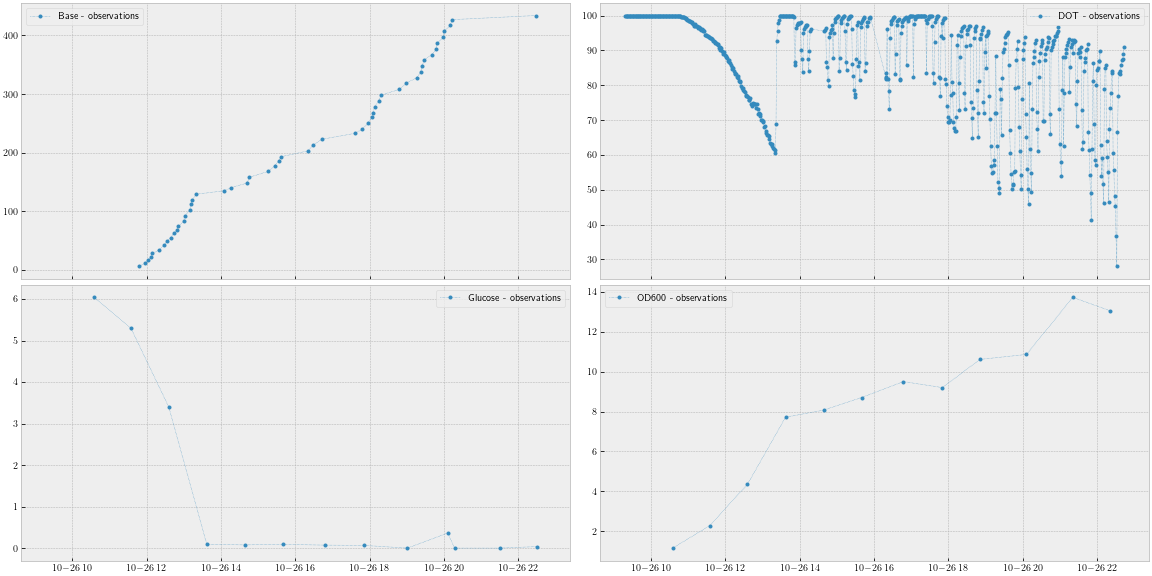

In [9]:
%matplotlib widget

fig, axes = plt.subplots(
    nrows=2, ncols=2, sharex=True, figsize=(16, 8), constrained_layout=True
)

for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
    data = ts[target]
    times = ts.index.values
    mask = ~np.isnan(data)
    ax.plot(
        times[mask],
        data[mask],
        ls=":",
        lw=0.5,
        marker=".",
        ms=6,
    )
    ax.legend([f"{target} - observations"])

### Add the model Forecast Plots

In [10]:
grid = np.linspace(0, len(slices)-1, num=8, dtype=int)
# grid = [0]
batches = slices.iloc[grid]

for batch in batches:
    make_plot(axes, task, batch)

fig.savefig(f"pics/test-{NAME.replace(r'/', r'_')}.pdf")

s
                     Flow_Air  StirringSpeed  Temperature   Acetate  \
measurement_time                                                      
2021-10-26 09:14:09 -0.008495     202.287384    37.086998  0.051973   
2021-10-26 09:14:23 -0.025257      -6.788635    37.131649  0.079964   
2021-10-26 09:14:51  0.000719      -7.332397    37.180099  0.073603   
2021-10-26 09:14:57  0.004921      -8.947632    37.186062  0.069146   
2021-10-26 09:15:01  0.002869      -9.560547    37.193825  0.064105   
...                       ...            ...          ...       ...   
2021-10-26 12:31:17  4.998273       3.715454    37.490303  0.141449   
2021-10-26 12:31:27  4.999402      -0.819092    37.484573  0.141573   
2021-10-26 12:32:29  4.999673       2.584595    37.529968  0.141971   
2021-10-26 12:32:33  4.999022      -0.874207    37.524036  0.141904   
2021-10-26 12:32:33  4.997982       2.738892    37.518177  0.141610   

                           Base  Cumulated_feed_volume_glucose  \
measurem

In [11]:
raise

RuntimeError: No active exception to reraise

## Creating per-channel plots for all channels

In [ ]:
def make_plot(axes, task, batch, target):
    """Helper function to create plot automatically."""
    # batch = slices[0]
    times, inputs, targets, originals = (x.to(device="cpu") for x in prep_batch(batch))
    outputs = model(times, inputs)

    times = times[0].detach().cpu()
    inputs = inputs[0].detach().cpu()
    outputs = outputs[0].detach().cpu()
    targets = targets[0].detach().cpu()
    originals = originals[0].detach().cpu()

    times.shape, outputs.shape, inputs.shape, targets.shape, originals.shape
    reconstructed = preprocessor.decode( (times, outputs) ).astype("float32")

    data = originals[:, idx]
    mask = ~np.isnan(data)
    ax.plot(
        reconstructed.index[:task.observation_horizon],
        reconstructed.iloc[:task.observation_horizon, idx],
        ls=":",
        lw=0.1,
        color="r",
    )
    ax.plot(
        reconstructed.index[task.observation_horizon-1:],
        reconstructed.iloc[task.observation_horizon-1:, idx],
        ls="-",
        lw=2,
        color="r",
    )
    print(reconstructed)

In [ ]:
columns = task.dataset.timeseries.columns

In [ ]:
%matplotlib widget

fig, axes = plt.subplots(
    nrows=2, ncols=2, sharex=True, figsize=(16, 8), constrained_layout=True
)

for target in task.targets.items()):
    data = ts[target]
    times = ts.index.values
    mask = ~np.isnan(data)
    ax.plot(
        times[mask],
        data[mask],
        ls=":",
        lw=0.5,
        marker=".",
        ms=6,
    )
    ax.legend([f"{target} - observations"])